# Training Dataset Analysis
## Complainify — processed_dataset_4500.csv

This notebook reads the actual CSV file and computes all statistics live, so numbers are always correct.

In [2]:
import csv, os, json
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

ModuleNotFoundError: No module named 'matplotlib'

In [3]:
# Load CSV
base = os.getcwd()
path = os.path.join(base, 'processed_dataset_4500.csv')
enc_path = os.path.join(base, 'encoders', 'category_decoder.json')

with open(path, encoding='utf-8') as f:
    rows = list(csv.DictReader(f))

with open(enc_path) as f:
    decoder = {int(k): v for k, v in json.load(f).items()}

encoder = {v: k for k, v in decoder.items()}
print(f'Loaded {len(rows):,} rows from processed_dataset_4500.csv')

Loaded 8,995 rows from processed_dataset_4500.csv


## 1. Overview Statistics

In [4]:
total = len(rows)
texts = [r['text'] for r in rows]
unique_texts = set(texts)
duplicates = total - len(unique_texts)
lens = [len(t) for t in texts]
slens = sorted(lens)

categories = sorted(set(r['category'] for r in rows))
cat_counts = Counter(r['category'] for r in rows)

print(f'Total Rows:        {total:,}')
print(f'Unique Texts:      {len(unique_texts):,}')
print(f'Duplicates:        {duplicates}')
print(f'Categories:        {len(categories)}')
print(f'Average Length:    {sum(lens)//len(lens)} chars')
print(f'Shortest:          {min(lens)} chars')
print(f'Longest:           {max(lens)} chars')
print(f'Median Length:     {slens[len(lens)//2]} chars')

Total Rows:        8,995
Unique Texts:      8,994
Duplicates:        1
Categories:        10
Average Length:    52 chars
Shortest:          19 chars
Longest:           469 chars
Median Length:     38 chars


## 2. Category Distribution

In [5]:
print(f'{"Category":25s} {"Code":6s} {"Count":8s} {"%":8s}')
print('-' * 50)
for code in sorted(decoder.keys()):
    name = decoder[code]
    count = cat_counts.get(name, 0)
    pct = count / total * 100
    print(f'{name:25s} {code:6d} {count:8d} {pct:7.1f}%')

Category                  Code   Count    %       
--------------------------------------------------
IT Support                     0      918    10.2%
Hostels                        1      918    10.2%
Academics                      2      932    10.4%
Fees / Finance                 3      918    10.2%
Maintenance                    4      918    10.2%
Transport                      5      918    10.2%
Security / Discipline          6      918    10.2%
Administration                 7      918    10.2%
Library                        8      819     9.1%
Canteen                        9      818     9.1%


In [6]:
labels = [decoder[i] for i in sorted(decoder.keys())]
values = [cat_counts.get(l, 0) for l in labels]
colors = ['#3b82f6','#6366f1','#8b5cf6','#ec4899','#f43f5e','#f59e0b','#10b981','#06b6d4','#94a3b8','#f97316']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, values, color=colors[:len(labels)], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val),
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Category Distribution', fontsize=14, fontweight='bold', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

## 3. Text Length Statistics

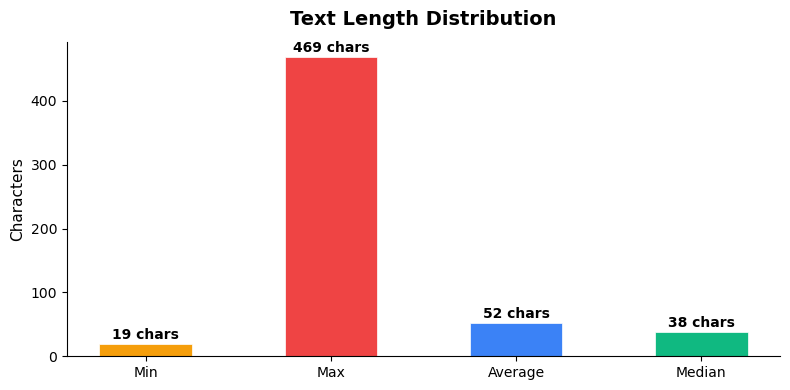

In [ ]:
metrics = ['Min', 'Max', 'Average', 'Median']
values2 = [min(lens), max(lens), sum(lens)//len(lens), slens[len(lens)//2]]
colors2 = ['#f59e0b', '#ef4444', '#3b82f6', '#10b981']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(metrics, values2, color=colors2, edgecolor='white', linewidth=0.5, width=0.5)
for bar, val in zip(bars, values2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, str(val) + ' chars',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Characters', fontsize=11)
ax.set_title('Text Length Distribution', fontsize=14, fontweight='bold', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Category Encoding

In [ ]:
print(f'{"Category":25s} {"Code":6s} {"Count":8s}')
print('-' * 42)
for code in sorted(decoder.keys()):
    name = decoder[code]
    count = cat_counts.get(name, 0)
    print(f'{name:25s} {code:6d} {count:8d}')

Category                  Code   Count   
------------------------------------------
IT Support                     0      918
Hostels                        1      918
Academics                      2      932
Fees / Finance                 3      918
Maintenance                    4      918
Transport                      5      918
Security / Discipline          6      918
Administration                 7      918
Library                        8      819
Canteen                        9      818


## 5. Priority Encoding

In [ ]:
priority_map = {'Medium': 0, 'Low': 1, 'High': 2}
print(f'{"Priority":10s} {"Code":6s} {"Index Type":20s}')
print('-' * 38)
for pri, code in priority_map.items():
    idx_type = {'Medium': 'Default (balanced)', 'Low': 'Low urgency', 'High': 'High urgency'}[pri]
    print(f'{pri:10s} {code:6d} {idx_type:20s}')

Priority   Code   Index Type          
--------------------------------------
Medium          0 Default (balanced)  
Low             1 Low urgency         
High            2 High urgency        


## 6. Sample Records (first 6)

In [ ]:
print(f'{"#":3s} {"Complaint Text":70s} {"Category":25s} {"Code":6s} {"Priority":10s}')
print('=' * 120)
for i, r in enumerate(rows[:6]):
    txt = r['text'][:67] + '...' if len(r['text']) > 70 else r['text']
    cat = r['category']
    code = str(encoder.get(cat, '?'))
    pri = r.get('priority', 'Medium')
    print(f'{i+1:3d} {txt:70s} {cat:25s} {code:6s} {pri:10s}')

#   Complaint Text                                                         Category                  Code   Priority  
  1 vpn intermittently disconnects during remote work connections drop ... IT Support                0      Medium    
  2 request to map departmental research share i need read write access... IT Support                0      Low       
  3 canvas submission blocked by sso loop right before deadline sign in... IT Support                0      High      
  4 matlab license request for course project i need matlab installed w... IT Support                0      Low       
  5 onedrive for education sync conflicts across lab and office pcs edi... IT Support                0      Medium    
  6 library printer queue stuck at processing jobs appear in the queue ... IT Support                0      Medium    


---
*All data loaded live from `processed_dataset_4500.csv` — no hardcoded values.*